📦 Carregando modelo salvo de: multi_task_model_vgg.pth
Todas as imagens possuem JSON correspondente.
🚀 Iniciando avaliação e plotagem das métricas...


C:\Users\ctw02813\AppData\Local\Temp\ipykernel_6784\2522795403.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


🔍 Avaliados 1/63 batches...
🔍 Avaliados 11/63 batches...
🔍 Avaliados 21/63 batches...
🔍 Avaliados 31/63 batches...
🔍 Avaliados 41/63 batches...
🔍 Avaliados 51/63 batches...
🔍 Avaliados 61/63 batches...

⏱️ Tempo total de avaliação: 1974.75 segundos

📊 Avaliação em 311 imagens:
🌤️ Acurácia Weather: 60.77%
🌆 Acurácia Scene:   80.06%
🌙 Acurácia Time:    90.35%
📦 Média de detecções (matched) por imagem: 0.23
🎯 Acurácia de categorias: 4.61%
📌 Detection Precision: 3.30%
📌 Detection Recall:    4.61%
📌 Detection F1 Score:  3.85%
📄 Avaliação salva em: logs/evaluate_log_vgg_extended.json

📑 Relatório de classificação - Weather:
               precision    recall  f1-score   support

           0       0.66      0.92      0.77       179
           2       0.22      0.14      0.17        28
           3       0.00      0.00      0.00        11
           4       1.00      0.07      0.13        28
           5       1.00      0.10      0.17        21
           6       0.42      0.39      0.40     

C:\Users\ctw02813\AppData\Local\anaconda3\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ctw02813\AppData\Local\anaconda3\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ctw02813\AppData\Local\anaconda3\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

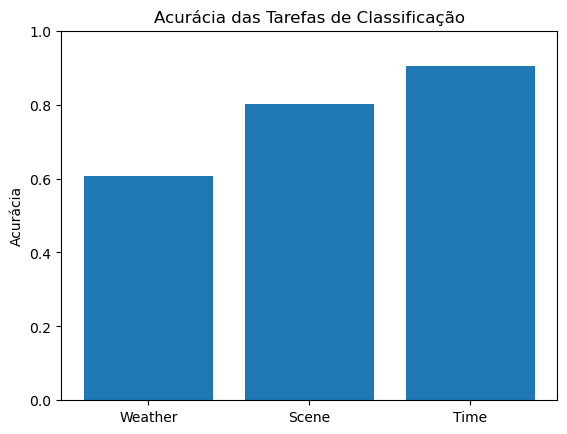

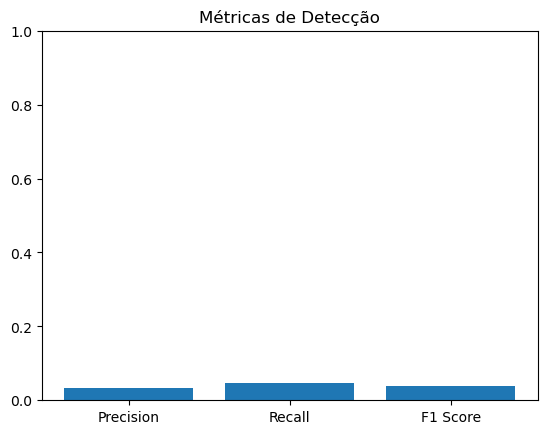

Gráfico salvo em: logs/matriz_de_confusão_-_weather_vgg.png


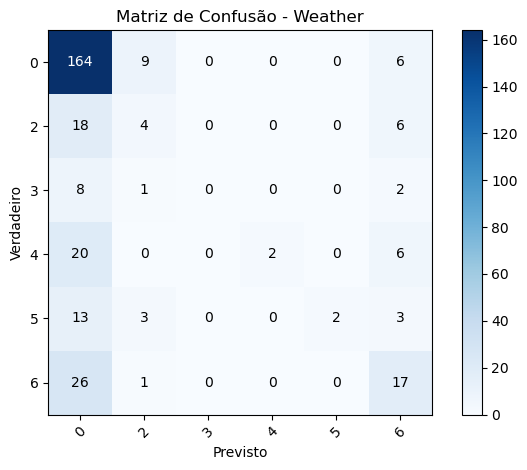

Gráfico salvo em: logs/matriz_de_confusão_-_scene_vgg.png


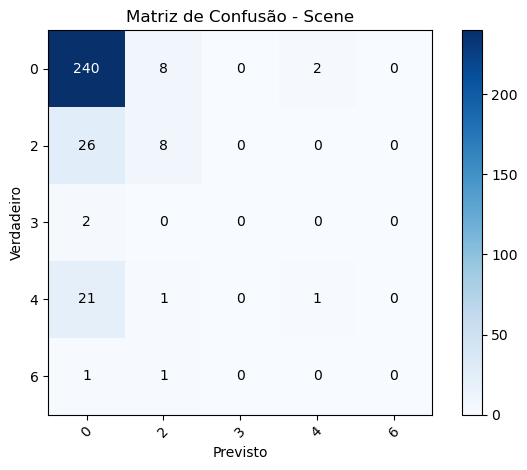

Gráfico salvo em: logs/matriz_de_confusão_-_time_vgg.png


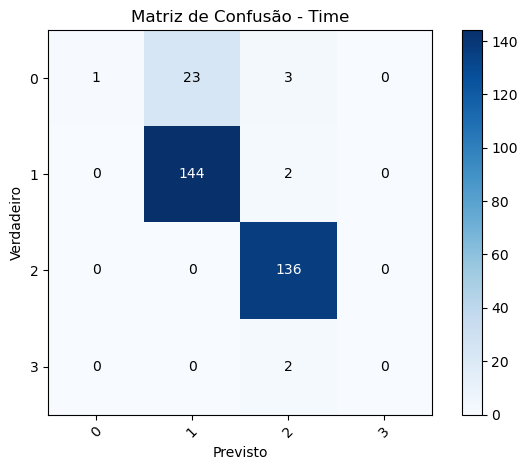

In [3]:
import json
import os
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# Importações para métricas de classificação
from sklearn.metrics import classification_report, confusion_matrix

from dataset_class import MultiTaskObjectDetectionDataset, collate_fn
from multi_task_model import MultiTaskModel

def compute_iou_torch(boxes1, boxes2):
    """
    Calcula o Intersection over Union (IoU) entre conjuntos de caixas.
    """
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter
    iou = inter / union
    return iou

def evaluate_and_plot(model, loader, device, model_type="default", iou_threshold=0.5, confidence_threshold=0.6):
    """
    Avalia o modelo e gera gráficos com métricas adicionais:
      - Para a detecção: calcula precision, recall e F1 Score baseados nas predições de caixas.
      - Para as tarefas de classificação (weather, scene, time): acumula predições, calcula relatórios e monta matrizes de confusão.
      - Gera gráficos de barras e salva as figuras em um diretório "logs".
    """
    start_time = time.time()
    model.eval()

    total = 0
    correct_weather, correct_scene, correct_time = 0, 0, 0
    total_gt = 0
    correct_category = 0
    detections_count = 0

    # Variáveis para métricas de detecção
    total_pred_boxes = 0
    true_positives_detection = 0
    total_gt_detections = 0

    # Listas para acumular as predições e rótulos reais dos classificadores
    all_weather_preds = []
    all_weather_true = []
    all_scene_preds = []
    all_scene_true = []
    all_time_preds = []
    all_time_true = []

    with torch.no_grad(), torch.cuda.amp.autocast():
        for batch_idx, (images, targets, attrs) in enumerate(loader):
            if not images:
                continue

            images = [img.to(device) for img in images]

            # Obtenção das predições do modelo
            outputs = model(images)
            detections = outputs if isinstance(outputs, list) else model.detection_model(images)
            w_logits, s_logits, t_logits = model.fc_weather, model.fc_scene, model.fc_timeofday

            # Processamento para tarefas de classificação
            feats = model.backbone(torch.stack(images))
            pooled = model.attr_pool(feats).view(len(images), -1)
            w_batch_preds = torch.argmax(w_logits(pooled), dim=1).to(device)
            s_batch_preds = torch.argmax(s_logits(pooled), dim=1).to(device)
            t_batch_preds = torch.argmax(t_logits(pooled), dim=1).to(device)

            # Acumulando os resultados para cada imagem do batch:
            for i in range(len(images)):
                all_weather_preds.append(w_batch_preds[i].cpu().item())
                all_scene_preds.append(s_batch_preds[i].cpu().item())
                all_time_preds.append(t_batch_preds[i].cpu().item())

            w_batch_true = torch.stack([a["weather"] for a in attrs]).to(device)
            s_batch_true = torch.stack([a["scene"] for a in attrs]).to(device)
            t_batch_true = torch.stack([a["timeofday"] for a in attrs]).to(device)

            for i in range(len(images)):
                all_weather_true.append(w_batch_true[i].cpu().item())
                all_scene_true.append(s_batch_true[i].cpu().item())
                all_time_true.append(t_batch_true[i].cpu().item())

            # Cálculo das acurácias de classificação em batch
            correct_weather += (w_batch_preds == w_batch_true).sum().item()
            correct_scene += (s_batch_preds == s_batch_true).sum().item()
            correct_time += (t_batch_preds == t_batch_true).sum().item()
            total += len(images)

            # Cálculo das métricas de detecção para cada imagem
            for i in range(len(images)):
                gt_boxes = targets[i]["boxes"].to(device)
                gt_labels = targets[i]["labels"].to(device)
                total_gt += len(gt_boxes)

                pred_boxes = detections[i]["boxes"].to(device)
                pred_labels = detections[i]["labels"].to(device)
                pred_scores = detections[i]["scores"].to(device)

                # Filtragem por threshold de confiança
                keep = pred_scores >= confidence_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                total_pred_boxes += len(pred_boxes)
                total_gt_detections += len(gt_boxes)

                if len(gt_boxes) == 0 or len(pred_boxes) == 0:
                    continue

                # Cálculo do IoU e correspondência das caixas
                ious = compute_iou_torch(gt_boxes, pred_boxes)
                max_iou, max_idx = ious.max(dim=1)
                matches = max_iou >= iou_threshold

                true_positives_detection += matches.sum().item()
                detections_count += matches.sum().item()
                # Verifica se as predições correspondem às categorias das caixas ground truth
                correct_category += (pred_labels[max_idx[matches]] == gt_labels[matches]).sum().item()

            if batch_idx % 10 == 0:
                print(f"🔍 Avaliados {batch_idx + 1}/{len(loader)} batches...")

    # Cálculo das métricas de classificação
    weather_acc = correct_weather / total if total > 0 else 0
    scene_acc = correct_scene / total if total > 0 else 0
    time_acc = correct_time / total if total > 0 else 0

    # Métricas de detecção
    detection_cat_acc = correct_category / total_gt if total_gt > 0 else 0
    avg_detections = detections_count / total if total > 0 else 0

    detection_precision = true_positives_detection / total_pred_boxes if total_pred_boxes > 0 else 0
    detection_recall = true_positives_detection / total_gt_detections if total_gt_detections > 0 else 0
    detection_f1 = (2 * detection_precision * detection_recall / (detection_precision + detection_recall)
                    if (detection_precision + detection_recall) > 0 else 0)

    total_time = time.time() - start_time
    print(f"\n⏱️ Tempo total de avaliação: {total_time:.2f} segundos")
    print(f"\n📊 Avaliação em {total} imagens:")
    print(f"🌤️ Acurácia Weather: {weather_acc:.2%}")
    print(f"🌆 Acurácia Scene:   {scene_acc:.2%}")
    print(f"🌙 Acurácia Time:    {time_acc:.2%}")
    print(f"📦 Média de detecções (matched) por imagem: {avg_detections:.2f}")
    print(f"🎯 Acurácia de categorias: {detection_cat_acc:.2%}")
    print(f"📌 Detection Precision: {detection_precision:.2%}")
    print(f"📌 Detection Recall:    {detection_recall:.2%}")
    print(f"📌 Detection F1 Score:  {detection_f1:.2%}")

    # Salvando os resultados em JSON
    evaluation = {
        "images": total,
        "accuracy_weather": round(weather_acc, 4),
        "accuracy_scene": round(scene_acc, 4),
        "accuracy_time": round(time_acc, 4),
        "average_detections_per_image": round(avg_detections, 2),
        "accuracy_categories": round(detection_cat_acc, 4),
        "detection_precision": round(detection_precision, 4),
        "detection_recall": round(detection_recall, 4),
        "detection_f1": round(detection_f1, 4),
        "evaluation_time_seconds": round(total_time, 2)
    }
    os.makedirs("logs", exist_ok=True)
    evaluate_path = f"logs/evaluate_log_{model_type}_extended.json"
    with open(evaluate_path, "w") as f:
        json.dump(evaluation, f, indent=4)
    print(f"📄 Avaliação salva em: {evaluate_path}")

    # Geração de relatórios de classificação utilizando o scikit-learn
    weather_report = classification_report(all_weather_true, all_weather_preds, output_dict=True)
    scene_report   = classification_report(all_scene_true, all_scene_preds, output_dict=True)
    time_report    = classification_report(all_time_true, all_time_preds, output_dict=True)
    print("\n📑 Relatório de classificação - Weather:\n", classification_report(all_weather_true, all_weather_preds))
    print("\n📑 Relatório de classificação - Scene:\n", classification_report(all_scene_true, all_scene_preds))
    print("\n📑 Relatório de classificação - Time:\n", classification_report(all_time_true, all_time_preds))

    # Plot dos resultados de acurácia nas tarefas de classificação
    tasks = ['Weather', 'Scene', 'Time']
    accuracies = [weather_acc, scene_acc, time_acc]
    plt.figure()
    plt.bar(tasks, accuracies)
    plt.title("Acurácia das Tarefas de Classificação")
    plt.ylabel("Acurácia")
    plt.ylim(0, 1)
    plt.savefig(f"logs/classification_accuracy_{model_type}.png")
    plt.show()

    # Plot das métricas de detecção
    detection_metrics = ['Precision', 'Recall', 'F1 Score']
    detection_values = [detection_precision, detection_recall, detection_f1]
    plt.figure()
    plt.bar(detection_metrics, detection_values)
    plt.title("Métricas de Detecção")
    plt.ylim(0, 1)
    plt.savefig(f"logs/detection_metrics{model_type}.png")
    plt.show()

    # Função auxiliar para plotar matrizes de confusão
    def plot_confusion(matrix, title, labels):
        plt.figure()
        plt.imshow(matrix, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(labels))
        plt.xticks(tick_marks, labels, rotation=45)
        plt.yticks(tick_marks, labels)
        fmt = 'd'
        thresh = matrix.max() / 2.
        for i, j in np.ndindex(matrix.shape):
            plt.text(j, i, format(matrix[i, j], fmt),
                     ha="center", va="center",
                     color="white" if matrix[i, j] > thresh else "black")
        plt.ylabel('Verdadeiro')
        plt.xlabel('Previsto')
        plt.tight_layout()
        save_path = f"logs/{title.replace(' ', '_').lower()}_{model_type}.png"
        plt.savefig(save_path)
        print(f"Gráfico salvo em: {save_path}")
        plt.show()

    # Matrizes de confusão para as tarefas de classificação
    weather_cm = confusion_matrix(all_weather_true, all_weather_preds)
    scene_cm = confusion_matrix(all_scene_true, all_scene_preds)
    time_cm = confusion_matrix(all_time_true, all_time_preds)
    plot_confusion(weather_cm, "Matriz de Confusão - Weather", np.unique(all_weather_true))
    plot_confusion(scene_cm, "Matriz de Confusão - Scene", np.unique(all_scene_true))
    plot_confusion(time_cm, "Matriz de Confusão - Time", np.unique(all_time_true))

    return evaluation

# Configurações do modelo e dataset
model_path = "multi_task_model_vgg.pth"
model_type = "vgg"
data_dir = "images/val"
label_dir = "labels/val"
batch_size = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📦 Carregando modelo salvo de: {model_path}")
model = torch.load(model_path, map_location=device, weights_only=False)
model = model.to(device)

transform = transforms.Compose([transforms.ToTensor()])
dataset = MultiTaskObjectDetectionDataset(data_dir, label_dir, transform)
subset_size = int(len(dataset) * 0.5)
indices = np.random.choice(len(dataset), subset_size, replace=False)
subset = Subset(dataset, indices)
loader = DataLoader(subset, batch_size=batch_size, collate_fn=collate_fn)

print("🚀 Iniciando avaliação e plotagem das métricas...")
evaluation_results = evaluate_and_plot(model, loader, device, model_type)
